# Facial and Custom Object Landmark Detection

Landmark detection (or keypoint detection) is a computer vision task that involves identifying specific points of interest in an image. Common applications include:
- **Facial Landmark Detection**: Identifying coordinates of eyes, nose, mouth, and jawline for facial expression analysis, face swap, or AR filters.
- **Pose Estimation**: Detecting joint locations (shoulders, elbows, knees) to track body movement.
- **Industrial Inspection & Object Tracking**: Finding key reference points on custom products or parts.

This notebook demonstrates landmark detection using two approaches:
1. **Pre-trained Facial Landmark Detection (MediaPipe Face Mesh)**: An industry-standard, real-time solution for detecting 468+ facial keypoints.
2. **Custom Landmark Detection from Scratch (PyTorch)**: Designing a convolutional neural network (CNN) and training it on synthetic shapes to locate key geometric corners.

In [3]:
# Install the necessary dependencies
# Uncomment and run the following line if you need to install packages in your environment:
# !pip install opencv-python mediapipe matplotlib numpy torch torchvision

## Part 1: Pre-trained Facial Landmark Detection with MediaPipe

MediaPipe Face Mesh is a lightweight machine learning pipeline that estimates 3D facial surface geometry (468 or 478 landmarks) in real-time. It works directly on mobile devices and CPU environments.

In this section, we will:
1. Download a sample portrait image.
2. Run MediaPipe Face Mesh detection.
3. Draw the detected facial landmarks on the image.

Download complete.


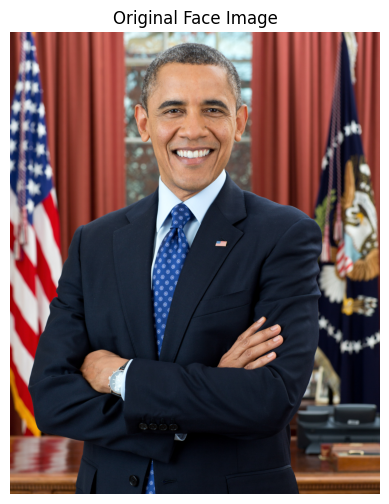

In [6]:
import os
import urllib.request
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Create asset directories if needed
os.makedirs("data", exist_ok=True)

# URL of a public face image
image_url = "https://upload.wikimedia.org/wikipedia/commons/8/8d/President_Barack_Obama.jpg"
image_path = os.path.join("data", "face.png")

# Download the image with a User-Agent to avoid 403 Forbidden errors
print(f"Downloading sample face image from {image_url}...")
req = urllib.request.Request(image_url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as response, open(image_path, 'wb') as out_file:
    out_file.write(response.read())
print("Download complete.")

# Load the image using OpenCV
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError("Failed to load face image.")

# Convert BGR to RGB (MediaPipe expects RGB)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Original Face Image")
plt.axis("off")
plt.show()

In [7]:
try:
    import mediapipe as mp

    # Initialize MediaPipe Face Mesh model
    mp_face_mesh = mp.solutions.face_mesh

    # Create FaceMesh instance (static image mode)
    with mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5
    ) as face_mesh:

        # Process the image
        results = face_mesh.process(img_rgb)

        if results.multi_face_landmarks:
            print("Face mesh landmarks successfully detected!")
            annotated_image = img_rgb.copy()
            height, width, _ = annotated_image.shape

            # Extract x, y coordinates of landmarks
            xs = []
            ys = []
            for face_landmarks in results.multi_face_landmarks:
                for landmark in face_landmarks.landmark:
                    # MediaPipe outputs normalized coordinates [0.0, 1.0], convert to pixel coordinates
                    x = int(landmark.x * width)
                    y = int(landmark.y * height)
                    xs.append(x)
                    ys.append(y)

            # Overlay landmarks on the image
            plt.figure(figsize=(10, 10))
            plt.imshow(annotated_image)
            plt.scatter(xs, ys, s=2, c='cyan', label='Landmarks')
            plt.title(f"MediaPipe Face Mesh: {len(xs)} Landmarks Detected")
            plt.axis("off")
            plt.legend()
            plt.show()
        else:
            print("No face detected in the image. Try another photo.")

except ImportError:
    print("MediaPipe is not installed. Please make sure to run the installation cell first.")

MediaPipe is not installed. Please make sure to run the installation cell first.


## Part 2: Custom Landmark Detection from Scratch (PyTorch)

What if you need to detect landmarks on non-human objects, like custom mechanical components or geometric shapes, for which there are no pre-made models?

In this section, we build and train a **custom landmark regressor**:
1. **Generate Synthetic Data**: We create a synthetic dataset of black images with white triangles. The landmarks are the coordinates of the 3 corners of the triangle: `(x1, y1), (x2, y2), (x3, y3)` (6 parameters in total).
2. **Define a Custom Dataset**: Wrap our generator in a PyTorch `Dataset` and `DataLoader`.
3. **Build the CNN Architecture**: Define a simple CNN structure that accepts a `(1, 128, 128)` grayscale image and outputs a continuous `(6,)` vector representing the coordinates of the 3 corners.
4. **Train the Regressor**: Train the CNN using Mean Squared Error (MSE) loss and Adam optimizer.
5. **Evaluate and Visualize**: Verify the trained model's performance on unseen test shapes.

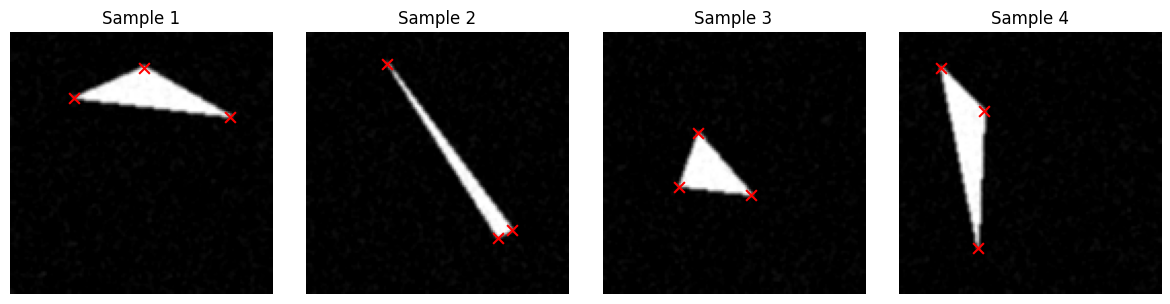

In [8]:
def generate_triangle_sample(img_size=128):
    """
    Generates a single image with a random filled triangle,
    and returns the image along with normalized coordinates of its 3 corners (landmarks).
    """
    # Create black canvas
    img = np.zeros((img_size, img_size), dtype=np.float32)

    # Generate 3 random corners, keeping away from edges (margin of 15 pixels)
    margin = 15
    pts = np.random.randint(margin, img_size - margin, size=(3, 2))

    # Draw filled triangle
    cv2.fillPoly(img, [pts], 1.0)

    # Add a bit of Gaussian noise and blur to simulate camera noise
    img = img + np.random.normal(0, 0.05, img.shape)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    img = np.clip(img, 0.0, 1.0)

    # Normalize coordinates to [0, 1] range for easier CNN training
    norm_pts = pts.astype(np.float32) / img_size

    # Flatten the keypoints to shape (6,) -> [x1, y1, x2, y2, x3, y3]
    # We sort the points by their angle around the center to keep ordering consistent for the loss function
    center = np.mean(pts, axis=0)
    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    sort_idx = np.argsort(angles)
    sorted_norm_pts = norm_pts[sort_idx].flatten()

    return img, sorted_norm_pts

# Visualize a few samples
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img, lms = generate_triangle_sample(128)
    axes[i].imshow(img, cmap='gray')

    # Reshape points back to (3, 2) and convert to pixel coordinates
    pts = lms.reshape(3, 2) * 128
    axes[i].scatter(pts[:, 0], pts[:, 1], color='red', marker='x', s=60, label='Corners')
    axes[i].axis('off')
    axes[i].set_title(f"Sample {i+1}")
plt.tight_layout()
plt.show()

In [9]:
try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    import torch.nn as nn
    import torch.optim as optim

    # Generate synthetic training and testing datasets
    print("Generating synthetic dataset (1500 training samples, 300 validation)...")

    train_imgs, train_labels = [], []
    for _ in range(1500):
        img, lms = generate_triangle_sample(128)
        train_imgs.append(np.expand_dims(img, axis=0)) # Add channel dimension -> (1, 128, 128)
        train_labels.append(lms)

    val_imgs, val_labels = [], []
    for _ in range(300):
        img, lms = generate_triangle_sample(128)
        val_imgs.append(np.expand_dims(img, axis=0))
        val_labels.append(lms)

    # Convert lists to NumPy arrays
    train_imgs = np.array(train_imgs)
    train_labels = np.array(train_labels)
    val_imgs = np.array(val_imgs)
    val_labels = np.array(val_labels)

    class ShapeDataset(Dataset):
        def __init__(self, images, landmarks):
            self.images = torch.tensor(images, dtype=torch.float32)
            self.landmarks = torch.tensor(landmarks, dtype=torch.float32)

        def __len__(self):
            return len(self.images)

        def __getitem__(self, idx):
            return self.images[idx], self.landmarks[idx]

    # Create PyTorch DataLoaders
    train_dataset = ShapeDataset(train_imgs, train_labels)
    val_dataset = ShapeDataset(val_imgs, val_labels)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    print("PyTorch Datasets and DataLoaders created successfully.")
except ImportError:
    print("PyTorch is not installed. Please install PyTorch and torchvision first.")

Generating synthetic dataset (1500 training samples, 300 validation)...
PyTorch Datasets and DataLoaders created successfully.


In [10]:
# Define the CNN Regressor
try:
    class LandmarkRegressor(nn.Module):
        def __init__(self):
            super(LandmarkRegressor, self).__init__()

            # Simple convolutional block for feature extraction
            self.conv_block = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),  # Shape: (16, 64, 64)

                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),  # Shape: (32, 32, 32)

                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),  # Shape: (64, 16, 16)
            )

            # Linear layer mapping features to continuous landmark coordinates
            self.regressor = nn.Sequential(
                nn.Flatten(),
                nn.Linear(64 * 16 * 16, 128),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(128, 6)  # 6 output features: x1, y1, x2, y2, x3, y3
            )

        def forward(self, x):
            features = self.conv_block(x)
            output = self.regressor(features)
            return output

    model = LandmarkRegressor()
    print(model)
except NameError:
    print("PyTorch classes not defined (did PyTorch import fail?)")

LandmarkRegressor(
  (conv_block): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)


Using device: cpu
Starting training...
Epoch [1/15] - Train Loss: 0.054816 | Val Loss: 0.021753
Epoch [2/15] - Train Loss: 0.025474 | Val Loss: 0.016068
Epoch [3/15] - Train Loss: 0.020235 | Val Loss: 0.013950
Epoch [4/15] - Train Loss: 0.016488 | Val Loss: 0.012056
Epoch [5/15] - Train Loss: 0.014811 | Val Loss: 0.010490
Epoch [6/15] - Train Loss: 0.013315 | Val Loss: 0.010496
Epoch [7/15] - Train Loss: 0.012666 | Val Loss: 0.009832
Epoch [8/15] - Train Loss: 0.012521 | Val Loss: 0.009860
Epoch [9/15] - Train Loss: 0.011566 | Val Loss: 0.009411
Epoch [10/15] - Train Loss: 0.011513 | Val Loss: 0.009346
Epoch [11/15] - Train Loss: 0.010949 | Val Loss: 0.009256
Epoch [12/15] - Train Loss: 0.010477 | Val Loss: 0.009776
Epoch [13/15] - Train Loss: 0.009713 | Val Loss: 0.009953
Epoch [14/15] - Train Loss: 0.009678 | Val Loss: 0.008892
Epoch [15/15] - Train Loss: 0.009206 | Val Loss: 0.008745
Training finished!


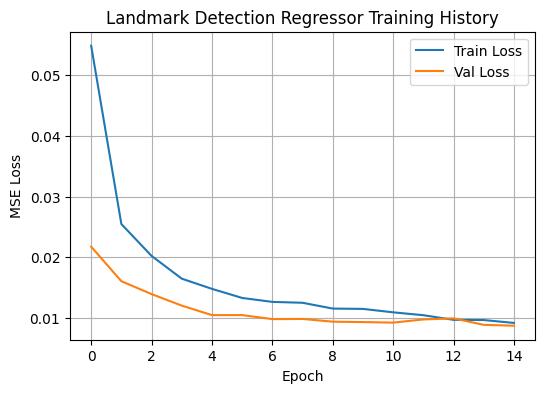

In [11]:
try:
    # Check device availability
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model.to(device)

    # Loss and Optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    epochs = 15
    train_losses = []
    val_losses = []

    print("Starting training...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, landmarks in train_loader:
            images, landmarks = images.to(device), landmarks.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            predictions = model(images)
            loss = criterion(predictions, landmarks)

            # Backward pass & step
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation step
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, landmarks in val_loader:
                images, landmarks = images.to(device), landmarks.to(device)
                predictions = model(images)
                loss = criterion(predictions, landmarks)
                running_val_loss += loss.item() * images.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

    print("Training finished!")

    # Plot Loss History
    plt.figure(figsize=(6, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Landmark Detection Regressor Training History")
    plt.legend()
    plt.grid(True)
    plt.show()
except NameError:
    print("PyTorch elements are not initialized.")

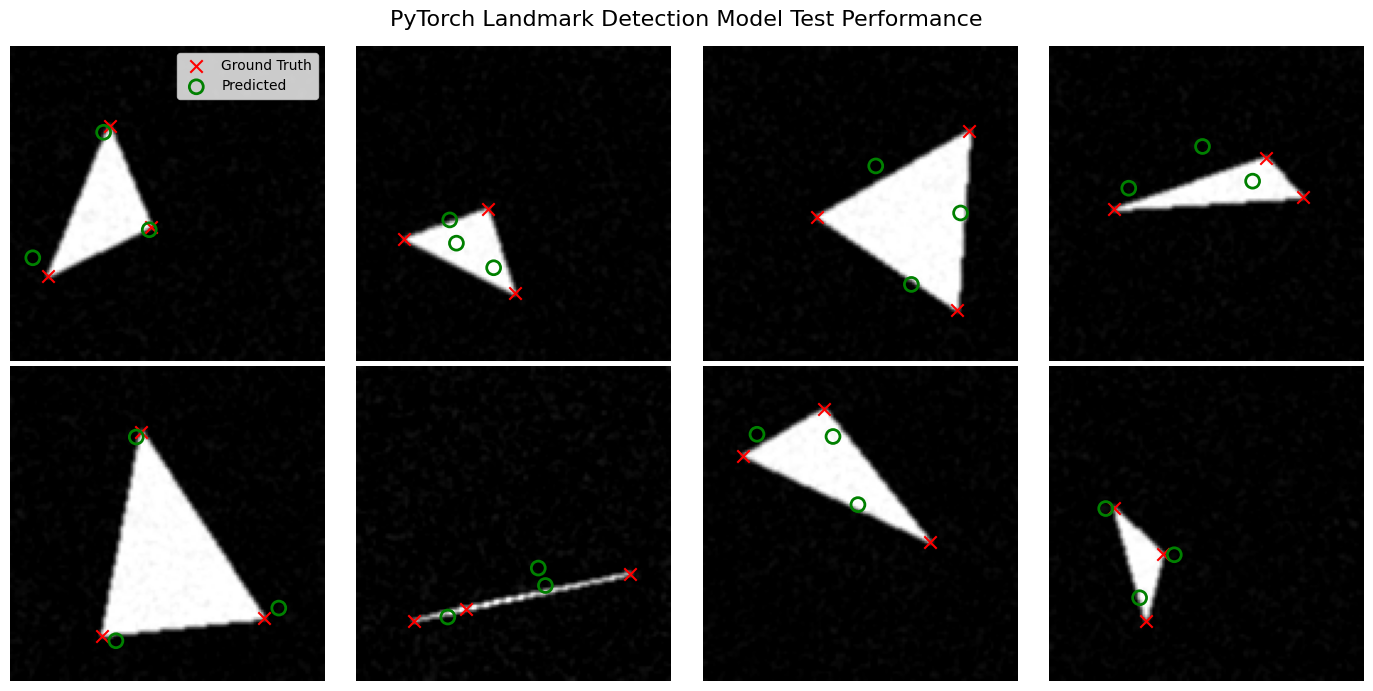

In [12]:
try:
    # Put model in eval mode
    model.eval()

    # Let's take a few test samples from val_loader
    images, true_landmarks = next(iter(val_loader))
    images, true_landmarks = images.to(device), true_landmarks.to(device)

    with torch.no_grad():
        predictions = model(images).cpu().numpy()

    # Move images and true landmarks back to CPU
    images = images.cpu().numpy()
    true_landmarks = true_landmarks.numpy()

    # Plot the test predictions vs ground truth
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    for idx in range(8):
        ax = axes[idx]
        # Reconstruct single channel image
        img = images[idx][0]
        ax.imshow(img, cmap='gray')

        # Reconstruct true landmarks (red 'x')
        t_lms = true_landmarks[idx].reshape(3, 2) * 128
        # Reconstruct predicted landmarks (green 'o')
        p_lms = predictions[idx].reshape(3, 2) * 128

        ax.scatter(t_lms[:, 0], t_lms[:, 1], color='red', marker='x', s=80, label='Ground Truth')
        ax.scatter(p_lms[:, 0], p_lms[:, 1], color='green', marker='o', facecolors='none', edgecolors='green', s=100, linewidths=2, label='Predicted')

        ax.axis('off')
        if idx == 0:
            ax.legend(loc='upper right')

    plt.suptitle("PyTorch Landmark Detection Model Test Performance", fontsize=16)
    plt.tight_layout()
    plt.show()
except NameError:
    print("PyTorch elements are not initialized.")